In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sfreq = 64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=16)
#dataset = BNCI2014008()
#subject, session, run = 1, "session_0", "run_0"

dataset = EPFLP300()
subject, session, run = 1, "session_1", "run_1"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
137 matching events found
No baseline correction applied


Number of events,137
Events,NonTarget: 114Target: 23
Time range,0.000 – 0.781 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


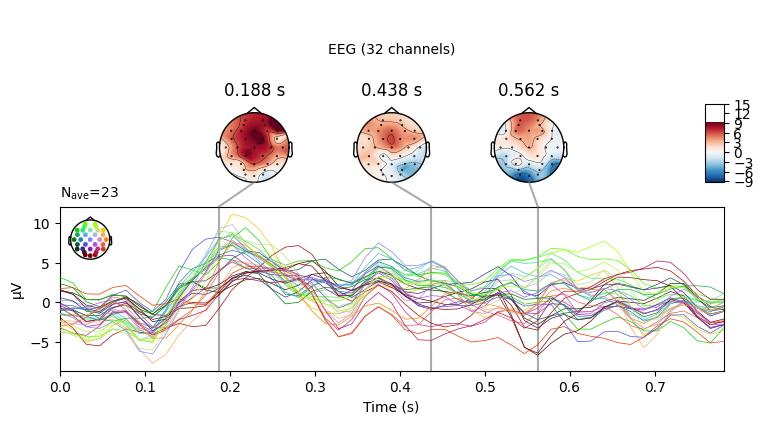

No projector specified for this dataset. Please consider the method self.add_proj.


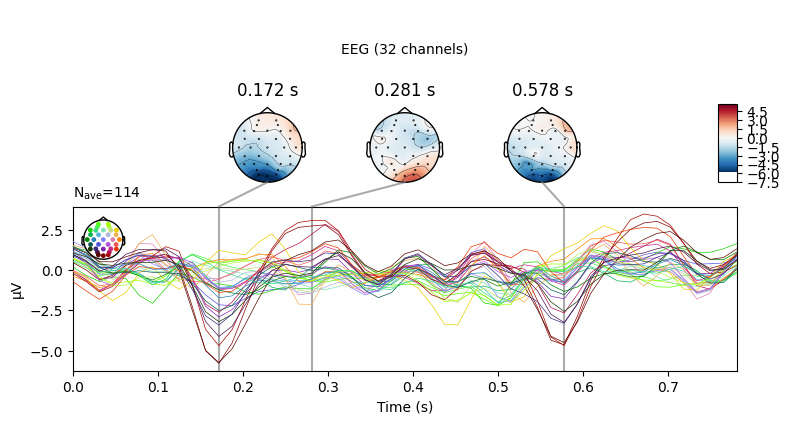

No projector specified for this dataset. Please consider the method self.add_proj.


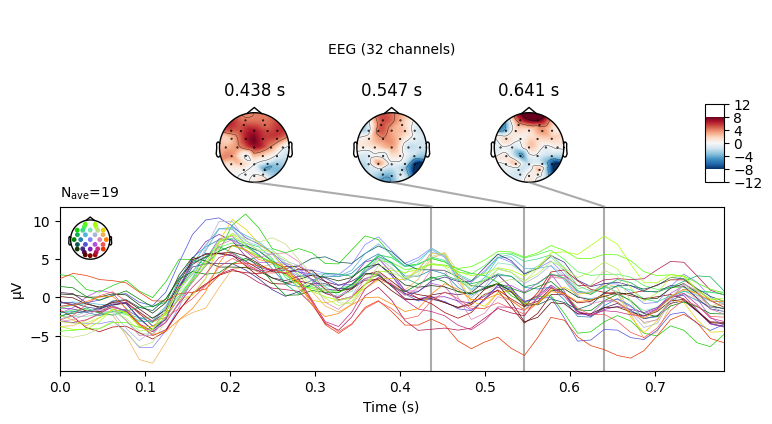

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint()
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
tmin = epochs.tmin
sfreq = epochs.info['sfreq']

def lagged_tensor(X, y=None):    
    window = .4
    max_lag = .4
    
    n_epochs, n_channels, _ = X.shape
    roi0 = int((0 - tmin)*sfreq)
    roi1 = int((window - tmin)*sfreq)
    n_times = roi1-roi0
    n_lags= int(max_lag*sfreq)
    Xt = np.zeros((n_epochs, n_channels, n_times, n_lags))
    for l in range(n_lags):
        Xt[:,:,:,l] = X[:,:,roi0+l:roi1+l]
    return Xt

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.hoda import MLSVD
from mne.decoding import Scaler
tl.set_backend('cupy')

X = epochs.get_data(picks='eeg')
split = len(epochs)//2
X_train = X[:split]
X_test = X[split:]
y_train = labels[:split]
y_test = labels[split:]


scaler = Scaler(scalings='mean', with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = lagged_tensor(X_train)
X_test = lagged_tensor(X_test)



#mlsvd = MLSVD(modes=(0,), rank=(16,))
#X_train = mlsvd.fit_transform(X_train)
#X_test = mlsvd.transform(X_test)
#factors = mlsvd.factors_
factors = [tl.eye(X_train.shape[1+k]) for k in range(len(X_train.shape[1:]))]

In [8]:
#fig, axs = plt.subplots(1, X_train.shape[1], figsize=(16,6))
#for i in range(X_train.shape[1]):
#    w = factors[0][:,i]
#    plot_topomap(w, epochs.info, axes=axs[i], show=False)
#plt.show()
#plt.plot(np.abs(X_train).mean(axis=(0,2,3)))

In [9]:
hoda = HODA(max_iter=128, rank=None, tol=1e-6,
            initialize ='svd', verbose=True,
            shrinkage=('oas', 'oas', 'oas'), toeplitz=(1,2), solver='diff-svd')
#%lprun -f hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)

/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'


[0/128]  shrinkage=0.0784  shrinkage=0.1209  shrinkage=0.1209  step=5.0370e+00
[1/128]  shrinkage=0.0781  shrinkage=0.1196  shrinkage=0.1196  step=3.8195e+00
[2/128]  shrinkage=0.0783  shrinkage=0.1205  shrinkage=0.1205  step=2.9182e+00
[3/128]  shrinkage=0.0781  shrinkage=0.1199  shrinkage=0.1199  step=2.1138e+00
[4/128]  shrinkage=0.0782  shrinkage=0.1204  shrinkage=0.1204  step=2.0464e+00
[5/128]  shrinkage=0.0780  shrinkage=0.1200  shrinkage=0.1200  step=1.9854e+00
[6/128]  shrinkage=0.0781  shrinkage=0.1203  shrinkage=0.1203  step=1.7850e+00
[7/128]  shrinkage=0.0780  shrinkage=0.1200  shrinkage=0.1200  step=1.7499e+00
[8/128]  shrinkage=0.0781  shrinkage=0.1203  shrinkage=0.1203  step=1.7213e+00
[9/128]  shrinkage=0.0780  shrinkage=0.1201  shrinkage=0.1201  step=1.6943e+00
[10/128]  shrinkage=0.0781  shrinkage=0.1203  shrinkage=0.1203  step=1.6134e+00
[11/128]  shrinkage=0.0780  shrinkage=0.1201  shrinkage=0.1201  step=1.9995e+00
[12/128]  shrinkage=0.0781  shrinkage=0.1202  shri

[112/128]  shrinkage=0.0781  shrinkage=0.1202  shrinkage=0.1202  step=1.8407e+00
[113/128]  shrinkage=0.0779  shrinkage=0.1202  shrinkage=0.1202  step=1.8402e+00
[114/128]  shrinkage=0.0781  shrinkage=0.1202  shrinkage=0.1202  step=1.8397e+00
[115/128]  shrinkage=0.0779  shrinkage=0.1202  shrinkage=0.1202  step=1.8391e+00
[116/128]  shrinkage=0.0781  shrinkage=0.1202  shrinkage=0.1202  step=1.8386e+00
[117/128]  shrinkage=0.0779  shrinkage=0.1202  shrinkage=0.1202  step=1.8381e+00
[118/128]  shrinkage=0.0781  shrinkage=0.1202  shrinkage=0.1202  step=1.8376e+00
[119/128]  shrinkage=0.0779  shrinkage=0.1202  shrinkage=0.1202  step=1.8371e+00
[120/128]  shrinkage=0.0781  shrinkage=0.1202  shrinkage=0.1202  step=1.8366e+00
[121/128]  shrinkage=0.0779  shrinkage=0.1202  shrinkage=0.1202  step=1.8361e+00
[122/128]  shrinkage=0.0781  shrinkage=0.1202  shrinkage=0.1202  step=1.8357e+00
[123/128]  shrinkage=0.0779  shrinkage=0.1202  shrinkage=0.1202  step=1.8352e+00
[124/128]  shrinkage=0.0781 

HODA(initialize='svd', max_iter=128, shrinkage=('oas', 'oas', 'oas'),
     solver='diff-svd', toeplitz=(1, 2), tol=1e-06, verbose=True)

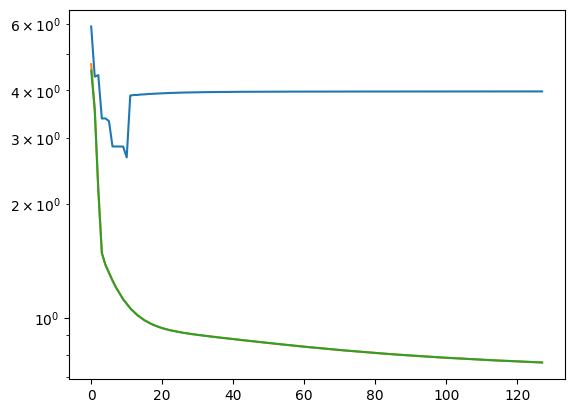

In [10]:
import cupy
plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

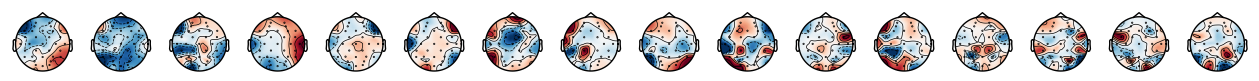

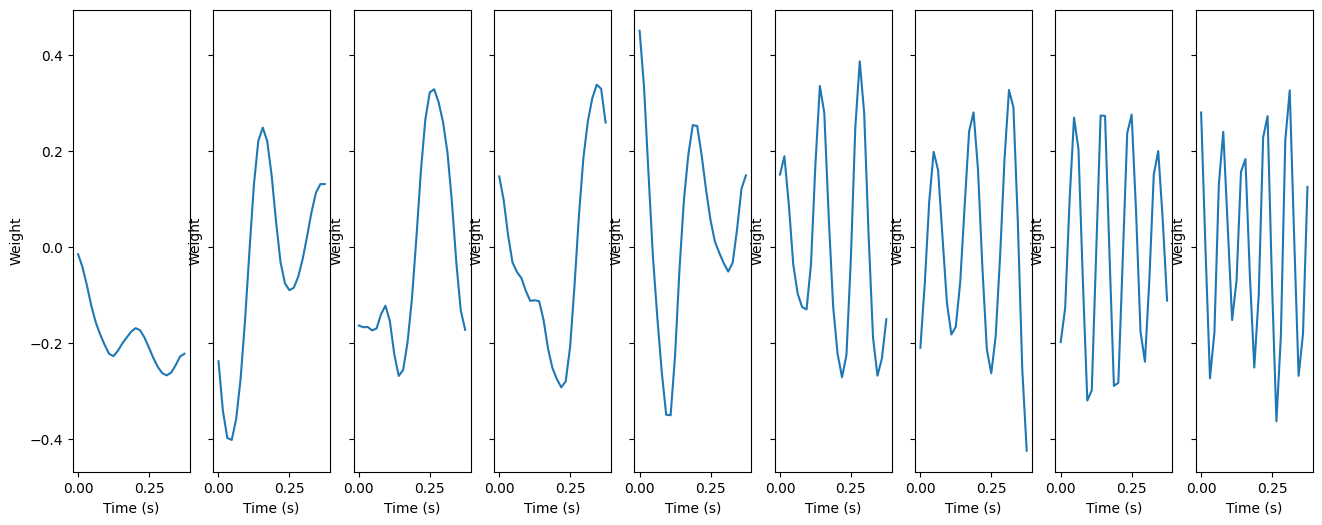

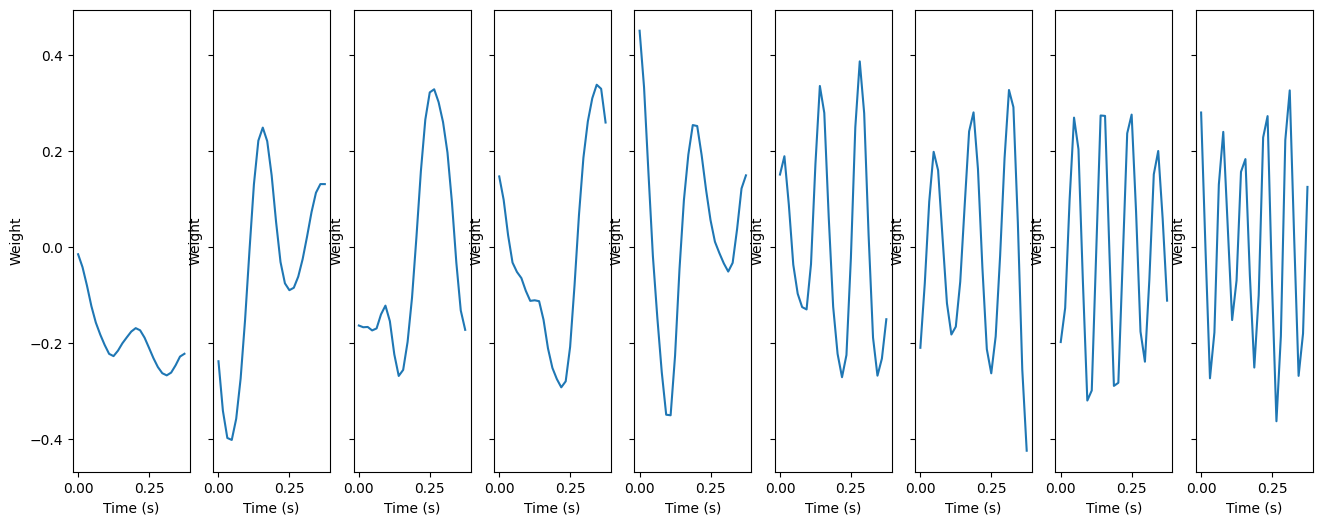

In [11]:
projs = [tl.to_numpy(factors[k] @ p) for k,p in enumerate(hoda.projs_)]

fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[i], show=False)

fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6), sharey=True)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank_[1]):
    w = projs[1][:,i]
    axs[i].plot(epochs.times[:len(w)], w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')

    
fig, axs = plt.subplots(1,hoda.rank_[2], figsize=(16,6), sharey=True)
for i in range(hoda.rank_[2]):
    w = projs[2][:,i]
    axs[i].plot(epochs.times[:len(w)], w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')


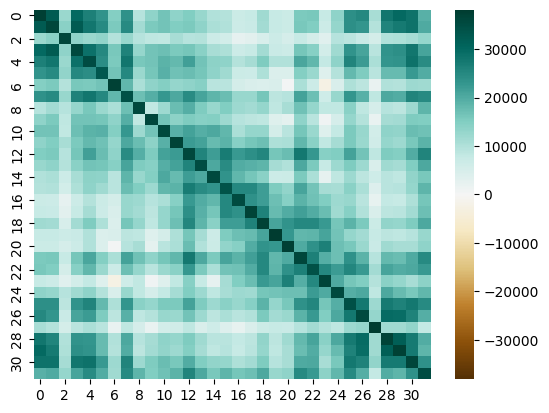

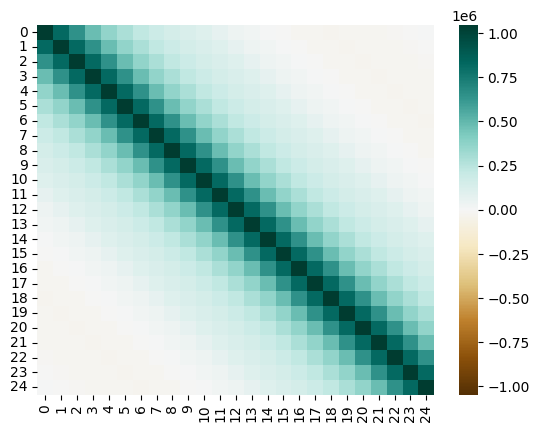

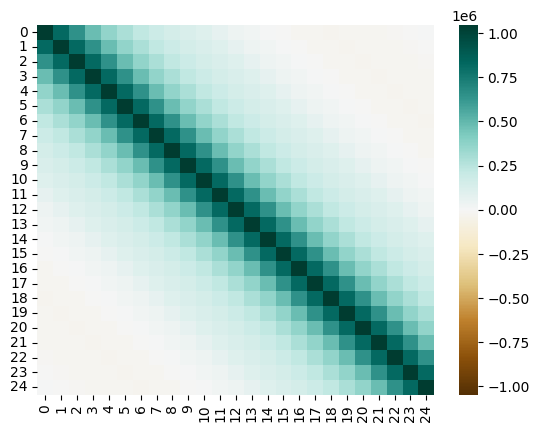

In [12]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    _ = sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    _ = plt.show()

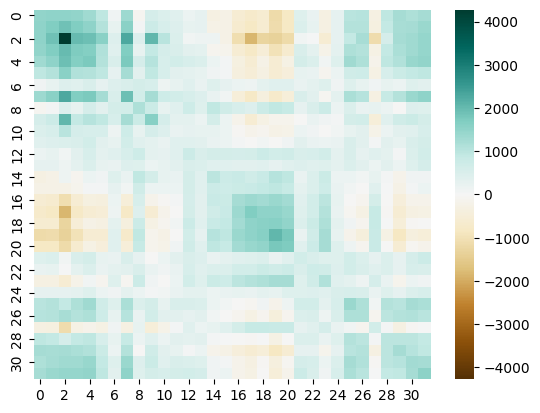

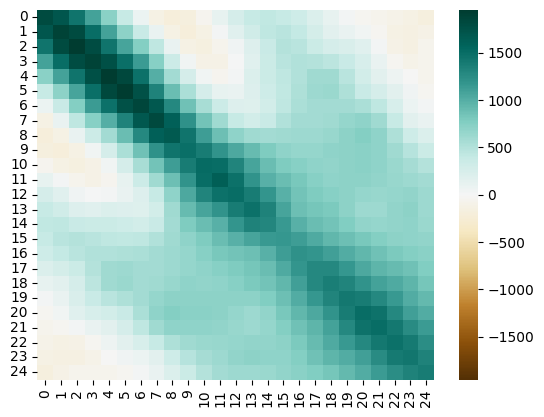

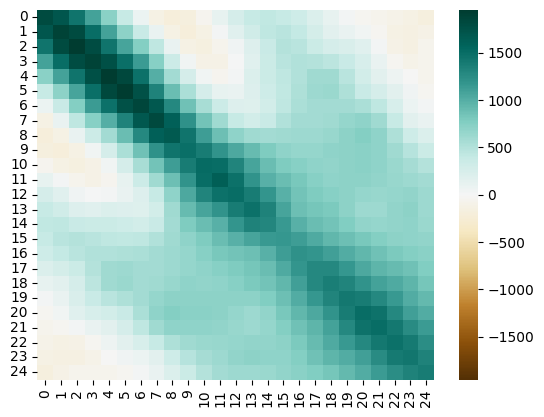

In [13]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

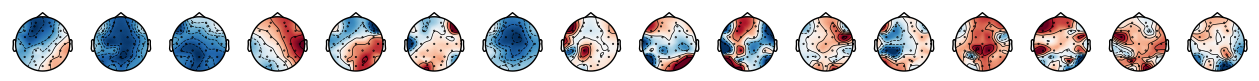

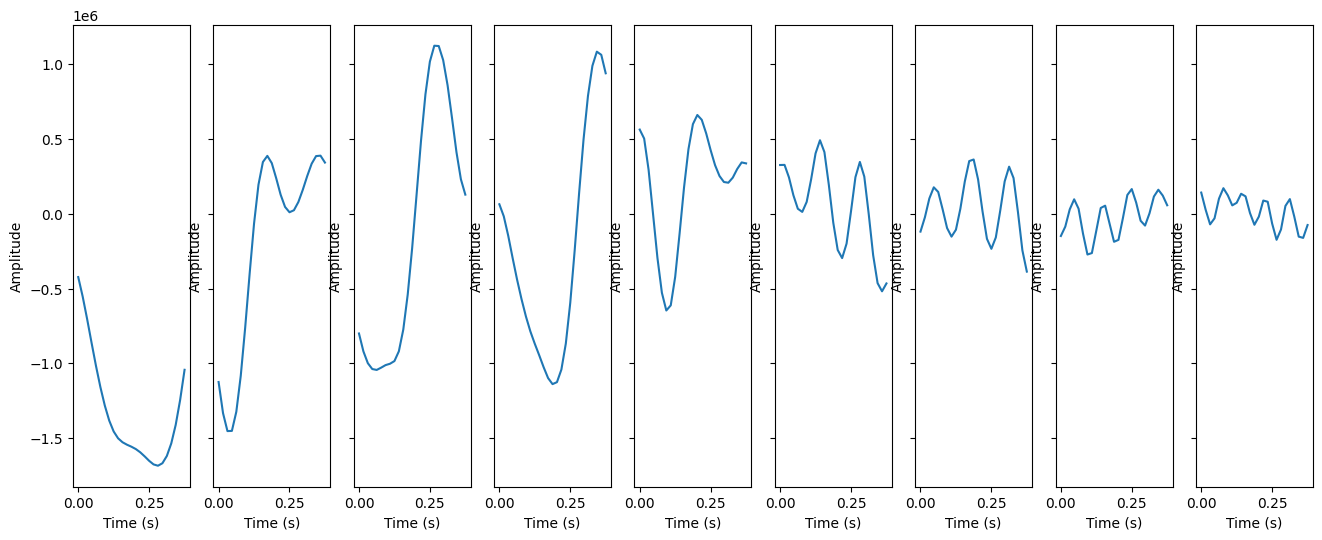

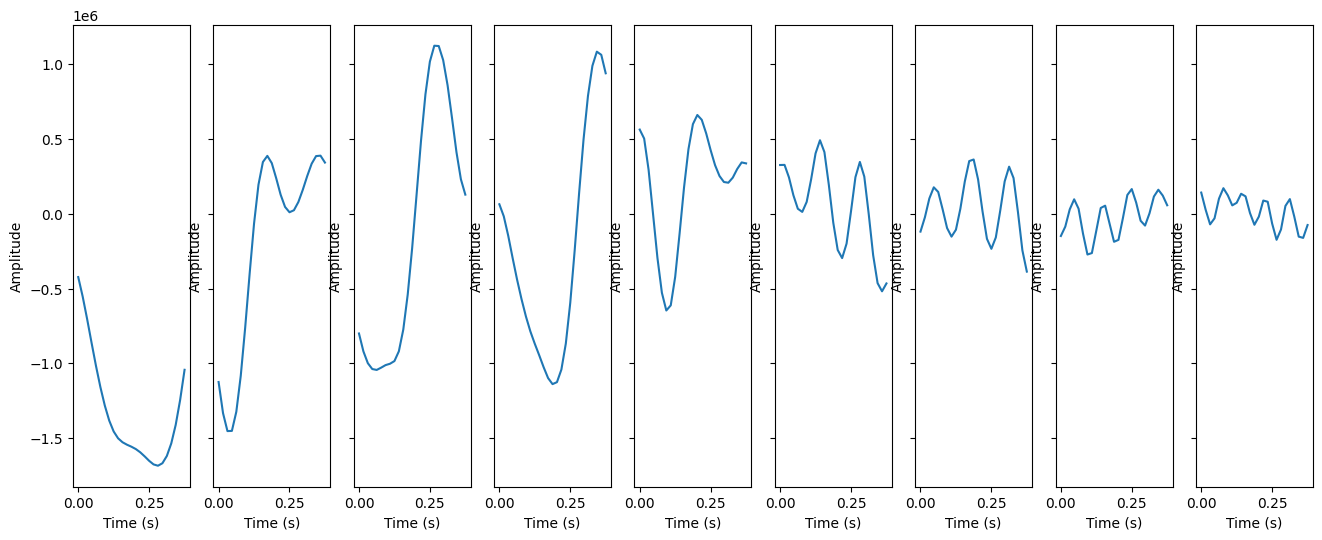

In [14]:
fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
aps = [cupy.asnumpy(factors[k] @ hoda.scatter_w_[k] @ p) for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank_[0]):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[i], show=False)

fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6), sharey=True)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank_[1]):
    w = aps[1][:,i]
    axs[i].plot(epochs.times[:len(w)], w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Amplitude')

    
fig, axs = plt.subplots(1,hoda.rank_[2], figsize=(16,6), sharey=True)
for i in range(hoda.rank_[2]):
    w = aps[2][:,i]
    axs[i].plot(epochs.times[:len(w)], w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Amplitude')


In [21]:

Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))


tril_idc = np.tril_indices(5)

Xt_train_tri = np.zeros((*Xt_train.shape[:2], len(tril_idc[0])))
for i in range(Xt_train_tri.shape[0]):
    for c in range(Xt_train_tri.shape[1]):
        Xt_train_tri[i,c] = Xt_train[i,c][tril_idc]
Xt_train = Xt_train_tri.reshape((Xt_train_tri.shape[0],-1))
        
Xt_test_tri = np.zeros((*Xt_test.shape[:2], len(tril_idc[0])))
for i in range(Xt_test_tri.shape[0]):
    for c in range(Xt_test_tri.shape[1]):
        Xt_test_tri[i,c] = Xt_test[i,c][tril_idc]
Xt_test = Xt_test_tri.reshape((Xt_test_tri.shape[0],-1))

"""
Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))
"""

'\nXt_train = Xt_train.reshape((Xt_train.shape[0],-1))\nXt_test = Xt_test.reshape((Xt_test.shape[0],-1))\n'

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

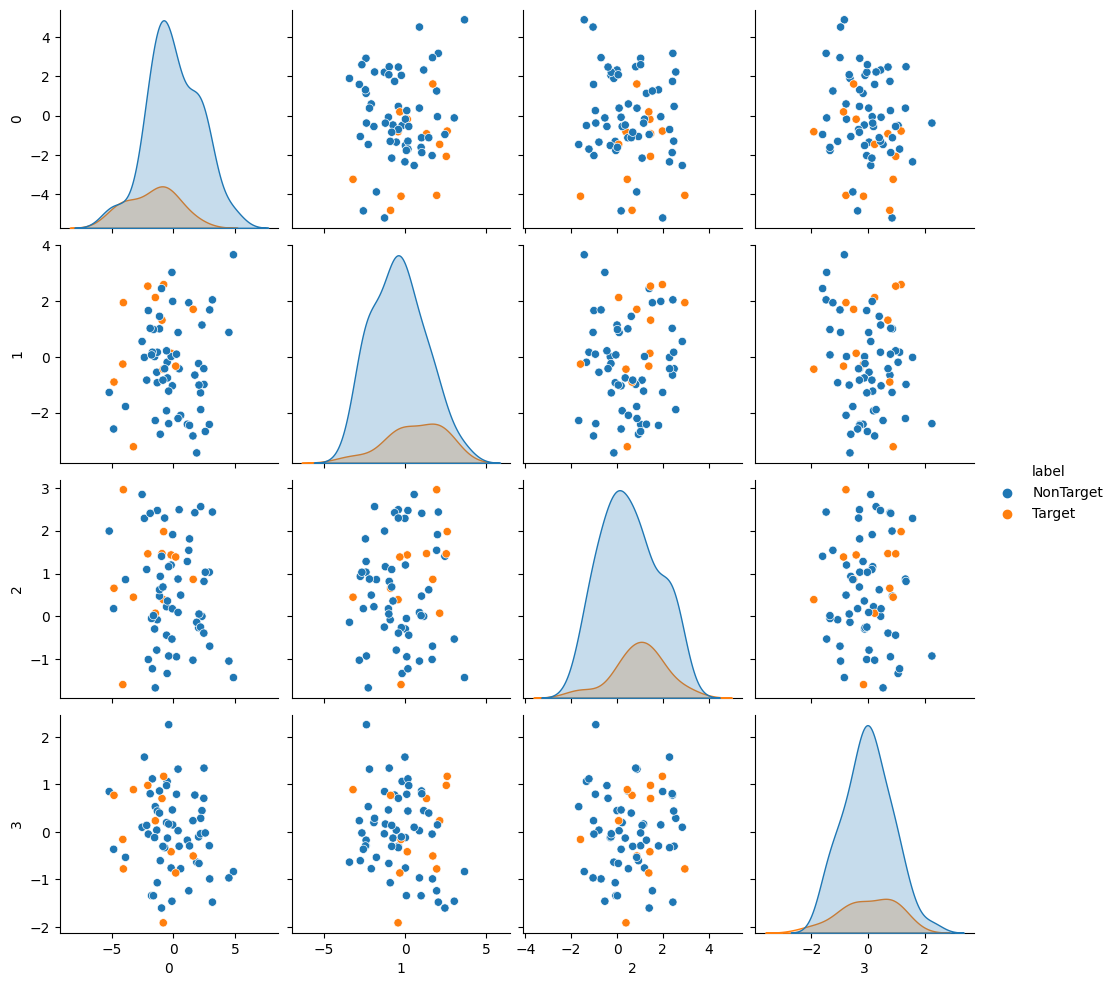

In [23]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [24]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

1.0

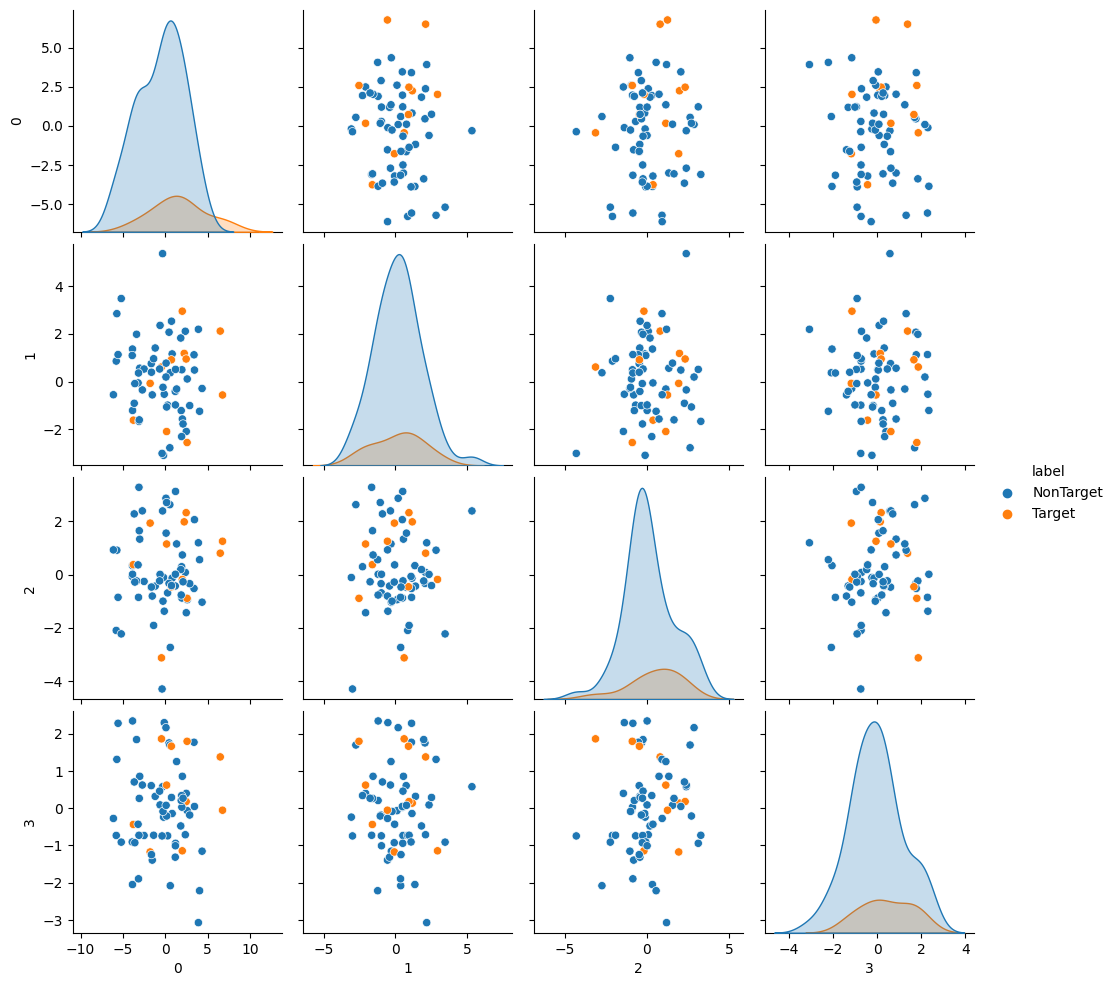

In [25]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [26]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.7053291536050157